# Magnification PDF explorer

The weak-lensing magnification distribution of a point source, computed by the sampling-free
solver of this repository for any source redshift, cosmology and lens model you choose.

**How to use:** edit the **knobs** cell below and *Run All*. Each PDF takes about 10-25 s. Results are
cached within a session, so re-running a plot cell or adding one redshift only computes what is new.

**The model:** NFW field halos (Sheth-Tormen abundance, Ludlow+16 concentrations) truncated at their
virial radii, pseudo-elliptical projections, filaments, subhalos (exact decorated-host quadrature), and
linear-bias clustering with the 3D linear correlation function (Limber). The lens population follows
Vaskonen (2026) and FLUMEN (Baltabay et al. 2026). It differs from their Monte Carlo engine in two
places: the virial truncation and the $\xi_{\rm lin}$ clustering. The derivation of each stage is in
`notebooks/sgl_analytic_walkthrough.ipynb`.

**Outputs:** the PDF on linear and log scales with the strong-lensing tail, tail probabilities
$P(\ln\mu > t)$, ratios to a reference cosmology, a table of moments, $\sigma_\kappa$ and the distance scatter
$\sigma_{D_L}/D_L$, an ingredient ladder, and CSV/JSON files of every PDF.

**Conventions:** $\mu$ is the magnification relative to a homogeneous universe, with distortions measured
from the mean of the modelled lenses. *Source plane* ($\mathrm dP_S$) is the distribution over source positions,
the one that applies to standard sirens and supernovae. *Image plane* ($\mathrm dP_I \propto \mu\,\mathrm dP_S$) is the
distribution over random lines of sight. $\sigma_{D_L}/D_L$ is the relative scatter of $D_L \propto \mu^{-1/2}$ (source plane).

In [1]:
import os, sys, json, time
from pathlib import Path
import numpy as np

REPO = Path.cwd()
while not (REPO / "src" / "pipeline.py").is_file():
    REPO = REPO.parent

# ============================== KNOBS: edit, then Run All ==============================

# Source redshifts: one PDF per z_s per cosmology.
ZS = [0.5, 1.0, 3.0, 10.0]

# Cosmologies to compare, name -> parameters. Allowed keys: h, Om, sigma8 (or s8), Ob, ns, zeq.
# Omitted keys take Planck 2018: h=0.674, Om=0.315, s8=0.811, Ob=0.0493, ns=0.965, zeq=3402.0.
# s8 is a real-space top-hat sigma_8. The FIRST entry is the reference of the ratio plots.
COSMOLOGIES = {
    "Planck 2018":   dict(),
    "sigma_8 = 0.87": dict(s8=0.87),
}

# Lens model: spherical NFW halos truncated at r_vir, plus
ELLIPTICITY = True    # pseudo-elliptical projections (Allgood+06 axis ratios)
FILAMENTS   = True    # cylindrical filaments, flat-barrier mass function
SUBHALOS    = True    # subhalos on their hosts, host mass reduced accordingly
CLUSTERING  = True    # linear-bias two-point term with xi_lin (Limber)

# Ingredient ladder at one z_s with the reference cosmology:
# halo -> +ellipticity -> +filaments -> +subhalos -> +clustering.  None = skip.
LADDER_ZS = 1.0

# Output
PLANE = "source"                    # "source" (dP_S) or "image" (dP_I)
LNMU_LOG_RANGE = (-0.8, 4.0)        # x range of the log-scale plots
TAIL_T = np.linspace(0.25, 5.0, 20) # thresholds t of P(ln mu > t)
SAVE_DIR = REPO / "output" / "explorer"   # CSV + JSON of every PDF; None = do not write

# Numerics: the defaults are converged, change them only to test convergence.
NUMERICS = dict(zint="midpoint",   # lens-z rule: "midpoint", "gauss" (zint_n nodes/shell), "engine" (MC's)
                zint_n=2,
                phi_tol=1e-8,      # |Phi| at the k-space cut
                grid_scale=1.0,    # multiplies every inversion grid size
                kap_floor=1e-8)    # where each halo's shear tail is cut
NPROC = os.cpu_count() or 1        # processes for the population build

# =======================================================================================

In [2]:
os.environ.setdefault("KMP_WARNINGS", "0")      # quiet libomp notices from build workers
sys.path[:0] = [str(REPO / "src")]
import pandas as pd
import matplotlib.pyplot as plt
import pipeline

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})
XI_BODY = np.linspace(-1.0, 1.0, 1601)        # ln mu grid of the body
XI_TAIL = np.linspace(1.005, 9.0, 1600)       # and of the tail (same normalisation)
MODEL = frozenset(n for n, f in (("ell", ELLIPTICITY), ("fil", FILAMENTS), ("sub", SUBHALOS),
                                 ("bias", CLUSTERING)) if f)
REF = next(iter(COSMOLOGIES))
_CACHE = globals().setdefault("_CACHE", {})

def pdf(zs, cosmo, model=MODEL):
    # one PDF from pipeline.run, cached on every input that changes it
    key = (float(zs), tuple(sorted(cosmo.items())), model, tuple(sorted(NUMERICS.items())))
    if key not in _CACHE:
        o, _ = pipeline.run(float(zs), set(model), cosmo=cosmo, nproc=NPROC,
                            xi_out=XI_BODY, xi_tail=XI_TAIL, **NUMERICS)
        x = np.r_[o["xi"], o["xi_tail"]]
        Ps = np.r_[o["P_s"], o["P_s_tail"]]
        o["x"], o["P_S"], o["P_I"] = x, Ps, pipeline.to_image_plane(x, Ps)
        o["clipped"] = pipeline.clipped_moments(np.asarray(o["xi"]), np.asarray(o["P_s"]))
        _CACHE[key] = o
    return _CACHE[key]

def P_of(o):
    return o["P_S"] if PLANE == "source" else o["P_I"]

YLAB = r"$\mathrm{d}P_S/\mathrm{d}\ln\mu$" if PLANE == "source" else r"$\mathrm{d}P_I/\mathrm{d}\ln\mu$"
print(f"lens model: {pipeline.cfg_name(MODEL)};  plane: {PLANE};  cosmologies: {list(COSMOLOGIES)};  "
      f"z_s: {ZS}")
t0 = time.time()
R = {(name, zs): pdf(zs, cp) for name, cp in COSMOLOGIES.items() for zs in ZS}
print(f"{len(R)} PDFs ready in {time.time() - t0:.0f} s")

lens model: full;  plane: source;  cosmologies: ['Planck 2018', 'sigma_8 = 0.87'];  z_s: [0.5, 1.0, 3.0, 10.0]


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


python(65706) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(65708) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(65709) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


...

python(67041) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(67042) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(67043) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(67044) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


8 PDFs ready in 369 s


## Summary table

All moments are of $\ln\mu$ in the source plane:
- *full*: over the solver moment interval (`grid.xi_min` to `grid.xi_max`), which varies with redshift;
- *clipped*: over $|\ln\mu|\le1$, renormalised there, which is robust to the far tail.

$\bar\kappa$ is the mean convergence of the modelled lenses, which the distortions are measured from.

In [3]:
rows = []
for (name, zs), o in R.items():
    rows.append({"cosmology": name, "z_s": zs, "sigma_kappa": o["sigma_kappa"],
                 "sigma_DL/D_L": o["sigmaDL"], "mean": o["mean"], "var": o["var"], "skew": o["skew"],
                 "clipped mean": o["clipped"]["mean"], "clipped var": o["clipped"]["var"],
                 "clipped skew": o["clipped"]["skew"], "kbar": o["kbar"], "time [s]": o["seconds"]})
table = pd.DataFrame(rows).set_index(["cosmology", "z_s"])
with pd.option_context("display.float_format", "{:.5g}".format):
    display(table)

sigma_kappa  sigma_DL/D_L       mean       var   skew  \
cosmology      z_s                                                          
Planck 2018    0.5     0.016553      0.015577 -0.0010608 0.0010248 3.5738   
               1       0.036984       0.03396 -0.0036342 0.0050219 2.6329   
               3       0.091204      0.079505  -0.019516   0.02875 1.7799   
               10       0.14785       0.12296  -0.050249  0.070836 1.4556   
sigma_8 = 0.87 0.5     0.017646      0.016498 -0.0012085 0.0011553 3.6894   
               1       0.039518      0.035951  -0.004134 0.0056711 2.7184   
               3       0.098062       0.08415  -0.022474  0.032539 1.8213   
               10       0.16024       0.13031  -0.058775  0.080489 1.4782   

                    clipped mean  clipped var  clipped skew     kbar  time [s]  
cosmology      z_s                                                              
Planck 2018    0.5    -0.0010531    0.0010313        3.7134 0.025489    86.219  
               1      -0.0037113    0.0049264        2.3632 0.086274    62.457  
               3       -0.020997     0.026723         1.305  0.38905     71.48  
               10      -0.056793     0.061653       0.90014  0.96278    49.443  
sigma_8 = 0.87 0.5    -0.0012008    0.0011617        3.8063 0.025951    27.961  
               1      -0.0042458    0.0055306        2.3837 0.088031    19.874  
               3       -0.024443     0.029818        1.2908   0.4005    24.028  
               10      -0.067175     0.068525       0.87575   1.0122    24.664

## The PDF

Left: the body on a linear scale. Right: log scale out to the strong-lensing tail. The dashed guide
is the fold-caustic asymptote, $\mathrm dP_S/\mathrm d\ln\mu \propto \mu^{-2}$ in the source plane ($\propto\mu^{-1}$ in the image plane).
Points left of the mode that fall below $10^{-5}$ of the peak are hidden. That region is below the
empty-beam edge, where the inversion has a numerical floor of oscillations at that level.

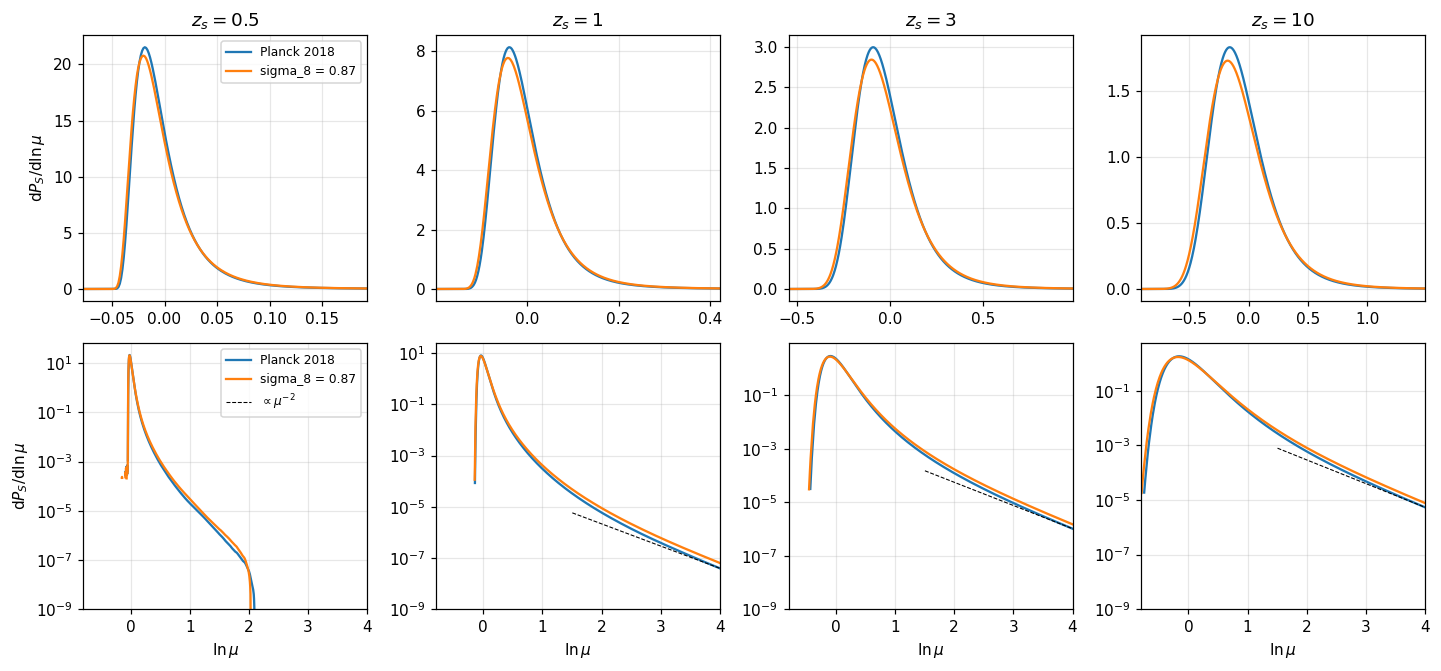

In [4]:
def shown(x, P):
    # hide the sub-edge numerical floor (left of the mode, below 1e-5 of the peak)
    i = int(np.argmax(P))
    return np.where((np.arange(P.size) < i) & (P < 1e-5 * P[i]), np.nan, P)

n = len(ZS)
fig, ax = plt.subplots(2, n, figsize=(3.3 * n, 6.2), squeeze=False)
slope = -2 if PLANE == "source" else -1
for j, zs in enumerate(ZS):
    for k, name in enumerate(COSMOLOGIES):
        o = R[(name, zs)]
        x, P = o["x"], P_of(o)
        ax[0, j].plot(x, P, f"C{k}", label=name)
        ax[1, j].semilogy(x, shown(x, P), f"C{k}", label=name)
    o = R[(REF, zs)]; x, P = o["x"], P_of(o)
    sd = np.sqrt(o["clipped"]["var"])
    i0 = np.searchsorted(x, 4.0)
    ax[1, j].semilogy(x[x > 1.5], P[i0] * np.exp(slope * (x[x > 1.5] - x[i0])), "k--", lw=0.7,
                      label=rf"$\propto\mu^{{{slope}}}$")
    ax[0, j].set(title=f"$z_s = {zs:g}$", xlim=(x[np.argmax(P > 1e-3 * P.max())] - sd, 6 * sd))
    ax[1, j].set(xlabel=r"$\ln\mu$", xlim=LNMU_LOG_RANGE, ylim=(1e-9, 3 * P.max()))
ax[0, 0].set_ylabel(YLAB); ax[1, 0].set_ylabel(YLAB)
ax[0, 0].legend(fontsize=8); ax[1, 0].legend(fontsize=8)
fig.tight_layout(); plt.show()

## Tail probabilities

$P(\ln\mu > t) = \int_t^{\infty}\mathrm d\ln\mu\,\mathrm dP/\mathrm d\ln\mu$, integrated on the computed grid, which reaches
$\ln\mu = 9$ (the remainder beyond is negligible). Comparing tail amplitudes with integrated probabilities is more
robust than comparing pointwise densities.

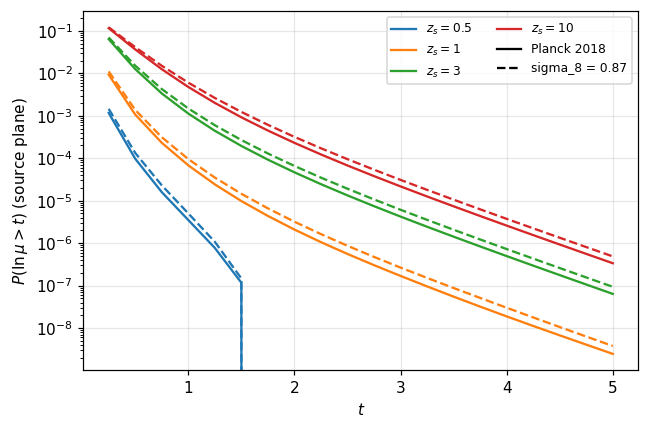

In [5]:
def tail_prob(x, P, t):
    out = []
    for tt in t:
        m = x >= tt
        out.append(np.trapezoid(P[m], x[m]))
    return np.array(out)

fig, ax = plt.subplots(figsize=(6, 4))
ls = ["-", "--", ":", "-."]
tail_rows = []
for j, zs in enumerate(ZS):
    for k, name in enumerate(COSMOLOGIES):
        o = R[(name, zs)]
        pt = tail_prob(o["x"], P_of(o), TAIL_T)
        ax.semilogy(TAIL_T, pt, color=f"C{j}", ls=ls[k % 4],
                    label=f"$z_s = {zs:g}$" if k == 0 else None)
        tail_rows += [{"cosmology": name, "z_s": zs, "t": t, "P(ln mu > t)": p} for t, p in zip(TAIL_T, pt)]
for k, name in enumerate(COSMOLOGIES):
    ax.plot([], [], "k", ls=ls[k % 4], label=name)
ax.set(xlabel="$t$", ylabel=r"$P(\ln\mu > t)$" + f" ({PLANE} plane)")
ax.legend(fontsize=8, ncol=2); fig.tight_layout(); plt.show()
tails = pd.DataFrame(tail_rows)
display(tails.pivot_table(index="t", columns=["cosmology", "z_s"], values="P(ln mu > t)")
        .iloc[::4].style.format("{:.3e}"))

## Ratio to the reference cosmology

Each cosmology divided by the first entry of `COSMOLOGIES`, shown where the reference PDF exceeds
$10^{-3}$ of its peak.

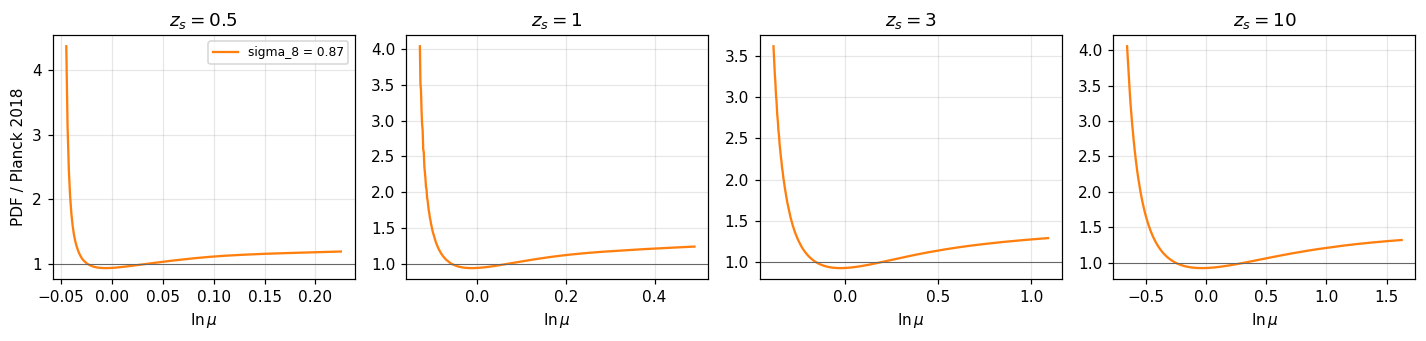

In [6]:
if len(COSMOLOGIES) < 2:
    print("only one cosmology in COSMOLOGIES: nothing to compare")
else:
    fig, ax = plt.subplots(1, n, figsize=(3.3 * n, 3.2), squeeze=False)
    for j, zs in enumerate(ZS):
        o0 = R[(REF, zs)]; x, P0 = o0["x"], P_of(o0)
        m = P0 > 1e-3 * P0.max()
        for k, name in enumerate(COSMOLOGIES):
            if name == REF:
                continue
            ax[0, j].plot(x[m], P_of(R[(name, zs)])[m] / P0[m], f"C{k}", label=name)
        ax[0, j].axhline(1, color="0.4", lw=0.7)
        ax[0, j].set(title=f"$z_s = {zs:g}$", xlabel=r"$\ln\mu$")
    ax[0, 0].set_ylabel(f"PDF / {REF}"); ax[0, 0].legend(fontsize=8)
    fig.tight_layout(); plt.show()

## Scatter versus source redshift

$\sigma_\kappa$ is the rms convergence, including clustering. $\sigma_{D_L}/D_L$ is the lensing scatter of the luminosity
distance, which sets the lensing error budget of a standard siren or supernova.

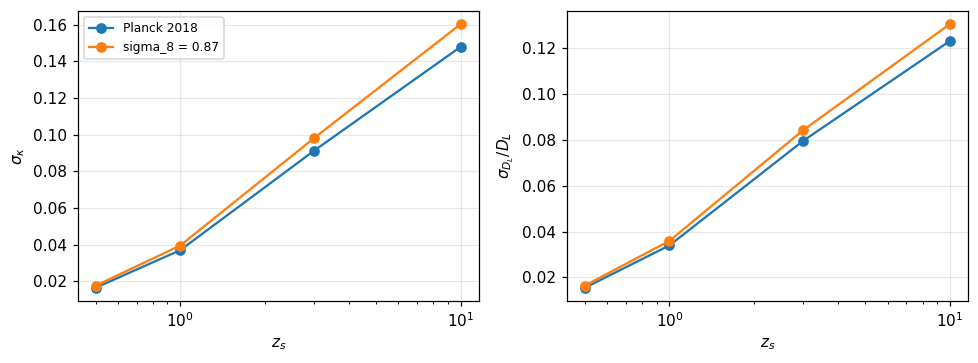

In [7]:
if len(ZS) < 2:
    print("only one z_s in ZS")
else:
    fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
    for k, name in enumerate(COSMOLOGIES):
        zz = sorted(ZS)
        ax[0].plot(zz, [R[(name, z)]["sigma_kappa"] for z in zz], f"C{k}o-", label=name)
        ax[1].plot(zz, [R[(name, z)]["sigmaDL"] for z in zz], f"C{k}o-", label=name)
    ax[0].set(xlabel="$z_s$", ylabel=r"$\sigma_\kappa$", xscale="log")
    ax[1].set(xlabel="$z_s$", ylabel=r"$\sigma_{D_L}/D_L$", xscale="log")
    ax[0].legend(fontsize=8); fig.tight_layout(); plt.show()

## Ingredient ladder

Each lens ingredient is added in turn at `LADDER_ZS`, with the reference cosmology. The ladder shows what
each one contributes to the width, the skewness and the tail.

python(67302) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(67303) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(67304) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(67305) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(67306) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


...

python(67589) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(67590) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(67591) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(67592) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(67593) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


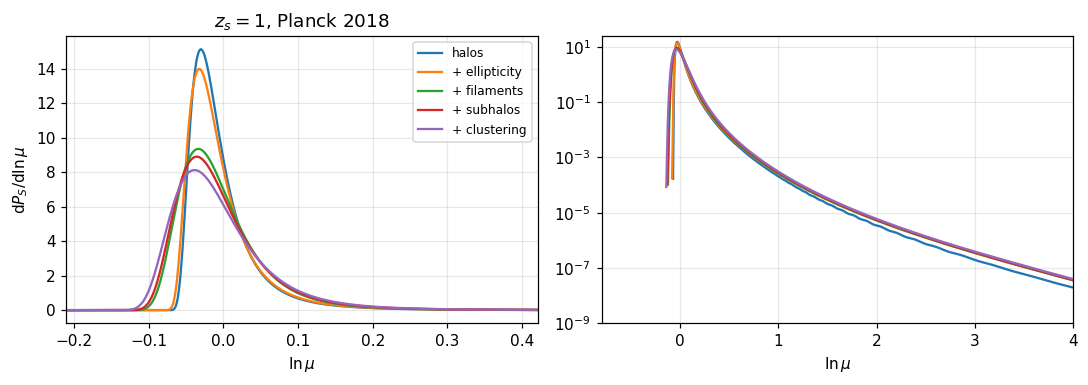

,sigma_kappa,clipped var,clipped skew,sigma_DL/D_L,P(ln mu > 1)
model,,,,,
halos,0.027866,0.0027224,3.7974,0.025033,4.4617e-05
+ ellipticity,0.029429,0.0030497,3.6615,0.026506,5.812e-05
+ filaments,0.033231,0.0039711,2.6524,0.03048,5.8958e-05
+ subhalos,0.034801,0.0043518,2.5609,0.031896,6.3035e-05
+ clustering,0.036984,0.0049264,2.3632,0.03396,6.8231e-05


In [8]:
if LADDER_ZS is None:
    print("LADDER_ZS = None: ladder skipped")
else:
    steps = [("halos", frozenset()), ("+ ellipticity", frozenset({"ell"})),
             ("+ filaments", frozenset({"ell", "fil"})), ("+ subhalos", frozenset({"ell", "fil", "sub"})),
             ("+ clustering", frozenset({"ell", "fil", "sub", "bias"}))]
    cp = COSMOLOGIES[REF]
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    lrows = []
    for k, (lab, mdl) in enumerate(steps):
        o = pdf(LADDER_ZS, cp, mdl)
        x, P = o["x"], P_of(o)
        ax[0].plot(x, P, f"C{k}", label=lab)
        ax[1].semilogy(x, shown(x, P), f"C{k}", label=lab)
        lrows.append({"model": lab, "sigma_kappa": o["sigma_kappa"], "clipped var": o["clipped"]["var"],
                      "clipped skew": o["clipped"]["skew"], "sigma_DL/D_L": o["sigmaDL"],
                      "P(ln mu > 1)": tail_prob(x, P, [1.0])[0]})
    sd = np.sqrt(lrows[-1]["clipped var"])
    ax[0].set(xlabel=r"$\ln\mu$", ylabel=YLAB, xlim=(-3 * sd, 6 * sd), title=f"$z_s = {LADDER_ZS:g}$, {REF}")
    ax[1].set(xlabel=r"$\ln\mu$", xlim=LNMU_LOG_RANGE, ylim=(1e-9, 3 * P.max()))
    ax[0].legend(fontsize=8); fig.tight_layout(); plt.show()
    with pd.option_context("display.float_format", "{:.5g}".format):
        display(pd.DataFrame(lrows).set_index("model"))

## Export

One CSV per (cosmology, $z_s$) with columns `ln_mu`, `dPS_dlnmu` and `dPI_dlnmu`. `summary.json` holds the table
above together with every knob, so each file can be traced to its inputs.

In [9]:
if SAVE_DIR is None:
    print("SAVE_DIR = None: nothing written")
else:
    SAVE_DIR = Path(SAVE_DIR); SAVE_DIR.mkdir(parents=True, exist_ok=True)
    files = []
    for (name, zs), o in R.items():
        tag = "".join(ch if ch.isalnum() else "_" for ch in name).strip("_")
        f = SAVE_DIR / f"pdf_{tag}_zs{zs:g}.csv"
        np.savetxt(f, np.column_stack([o["x"], o["P_S"], o["P_I"]]), delimiter=",",
                   header="ln_mu,dPS_dlnmu,dPI_dlnmu", comments="")
        files.append(f.name)
    summary = dict(knobs=dict(ZS=ZS, COSMOLOGIES=COSMOLOGIES, model=pipeline.cfg_name(MODEL),
                              NUMERICS=NUMERICS),
                   results=[{"cosmology": k[0], "z_s": k[1],
                             **{c_: (float(v) if np.ndim(v) == 0 else v) for c_, v in row.items()}}
                            for k, row in table.to_dict("index").items()],
                   cosmology_resolved={name: {p: R[(name, ZS[0])][p] for p in ("h", "Om", "sigma8", "Ob", "ns", "zeq")}
                                       for name in COSMOLOGIES})
    (SAVE_DIR / "summary.json").write_text(json.dumps(summary, indent=1))
    print(f"wrote {len(files)} CSV files + summary.json to {SAVE_DIR}")

wrote 8 CSV files + summary.json to /Users/baltabay/Desktop/sGL_analytic/output/explorer
